In [2]:
import sys
from pathlib import Path
# sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms').resolve()))
sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle
import os
# List of layouts
np.random.seed(212)


# A bit different functions

In [17]:

def draw_five_layouts(G, graph_id, pos_generated_from_rgg, node_size=150):
    G_ig = ig.Graph.TupleList(nx.to_edgelist(G), directed=False)
    missing_vertices = set(G.nodes()) - set(G_ig.vs['name'])
    G_ig.add_vertices(list(missing_vertices))
    layouts = [
        # nx.circular_layout(G),
        nx.kamada_kawai_layout(G),
        nx.random_layout(G),
        # point_to_segment_distance,
        nx.random_layout(G),
        nx.random_layout(G),
        nx.random_layout(G),
        nx.random_layout(G),

    ]

    layout_names = ['kamada_kawai','pos from RGG', 'random_no1', 'random_no2', 'random_no3', 'random_no4']
    # Create a 2x7 subplot
    fig, axes = plt.subplots(1, 6, figsize=(22, 3.5))
 
    # Draw the graph using each layout
    for ax, pos, layout_name in zip(axes.flatten(), layouts, layout_names):
        # pos = layout(G)
        # rescaling to make all the rangesfrom -1 to 1
        if layout_name == 'lgl':
            pos = rescale_igraph_pos(pos)
            print(pos)

        if layout_name == 'pos from RGG':
            pos = pos_generated_from_rgg
    
        nx.draw(G, pos, with_labels=True, edge_color='gray', node_size=node_size, font_size=10, ax=ax)
        ax.set_title(layout_name)

    file_path = f'layouts_img/{graph_id}_all_layouts_img.png'
    fig.savefig(file_path)
        
    plt.show()
    return layouts



def save_posdfs(G, layouts, graph_id, pos_generated_from_rgg):
    layout_names = ['kamada_kawai', 'pos from RGG', 'random_no1', 'random_no2', 'random_no3', 'random_no4']

    # Save each layout to a file
    for layout, name in zip(layouts, layout_names):
        
        if name == 'pos from RGG':
            layout = pos_generated_from_rgg

        # for networx
        if name.startswith('random') or name in ['kamada_kawai']:
            posdf = pd.DataFrame.from_dict(layout, orient='index', columns=['X', 'Y'])
        elif name in ['pos from RGG']:
            posdf = pd.DataFrame.from_dict(layout, orient='index', columns=['X', 'Y'])
            posdf = rescale_dataframe_coords(posdf)
        else:
        # for igraph
            posdf = pd.DataFrame(layout.coords, columns=['X', 'Y'])
            posdf = rescale_dataframe_coords(posdf)

        file_path = f'pos_dfs/{graph_id}_{name}.csv'

        posdf.to_csv(file_path, index=False)


    file_path = f'graph_objects/graph_{graph_id}.pkl'
    with open(file_path, 'wb') as f:
        pickle.dump(G, f)


### Testing rescaling

In [7]:
n = 10 
radius = 0.3
G = nx.random_geometric_graph(n, radius)

# Plot the generated graph
pos = nx.get_node_attributes(G, 'pos')
posdf = pd.DataFrame.from_dict(pos, orient='index', columns=['X', 'Y'])


In [6]:
pos

{0: [0.2679801120832672, 0.13051227557358935],
 1: [0.14567773282208385, 0.923428062672787],
 2: [0.045645644945998765, 0.13841621612839694],
 3: [0.6481797245600484, 0.8513574119831213],
 4: [0.7724573560009718, 0.5488723045121194],
 5: [0.5983640927381477, 0.10707279989055907],
 6: [0.7439988744659299, 0.4517971213209381],
 7: [0.6378015663348359, 0.527746941342283],
 8: [0.8788979885831723, 0.3457825719924089],
 9: [0.38154039650288996, 0.27302795378783273]}

In [8]:
rescale_dataframe_coords(posdf)

,X,Y
0,0.088568,-0.875935
1,-0.231969,-0.535835
2,1.000000,0.750005
3,-0.602815,0.693766
4,-0.464666,1.000000
5,-1.000000,0.880117
6,-0.856242,-1.000000
7,-0.485043,-0.659526
8,0.955773,0.663466
9,0.271974,-0.401054


# Example

In [ ]:
# %load_ext autoreload
# %autoreload 3
# from graph_metric_script import *

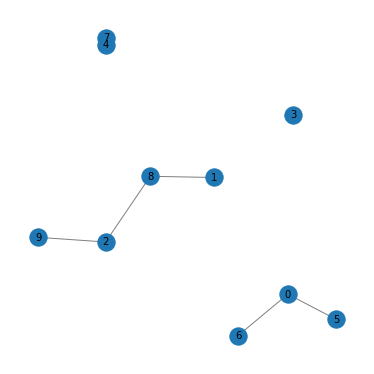

In [19]:
np.random.seed(212)
n = 10  # Number of nodes
radius = 0.3  # Distance threshold value
G = nx.random_geometric_graph(n, radius)

# Plot the generated graph
pos_generated_from_rgg = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(5,5))
nx.draw(G, pos_generated_from_rgg, with_labels=True, edge_color='gray', node_size=300, font_size=10)


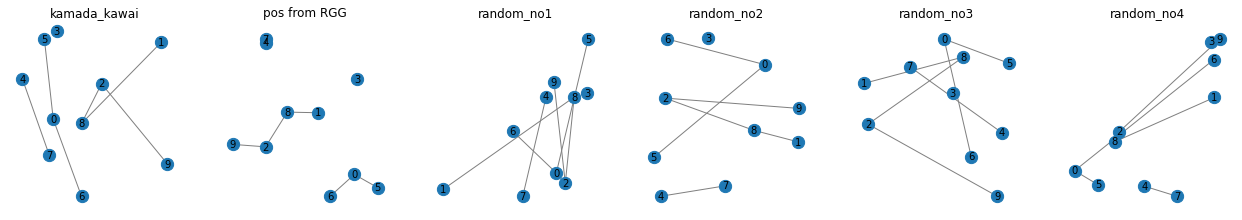

In [20]:
layouts = draw_five_layouts(G, 0, pos_generated_from_rgg)
save_posdfs(G, layouts, 0, pos_generated_from_rgg)

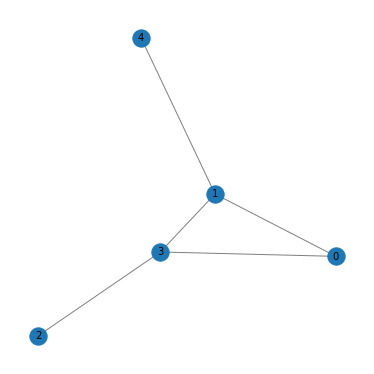

In [25]:
np.random.seed(212)
n = 5  # Number of nodes
radius = 0.5  # Distance threshold value
G = nx.random_geometric_graph(n, radius)

# Plot the generated graph
pos_generated_from_rgg = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(5,5))
nx.draw(G, pos_generated_from_rgg, with_labels=True, edge_color='gray', node_size=300, font_size=10)


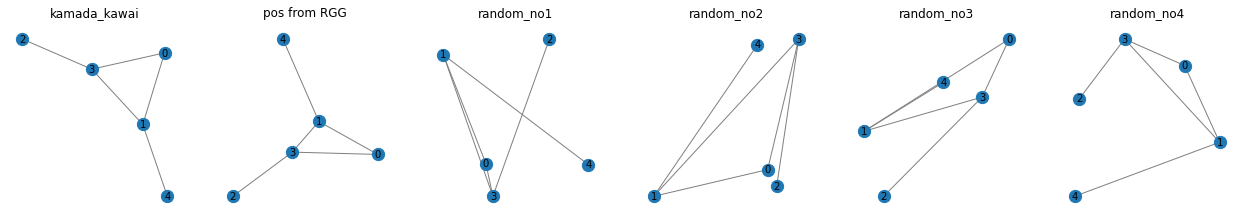

In [26]:
layouts = draw_five_layouts(G, 1, pos_generated_from_rgg)
save_posdfs(G, layouts, 1, pos_generated_from_rgg)

# 2

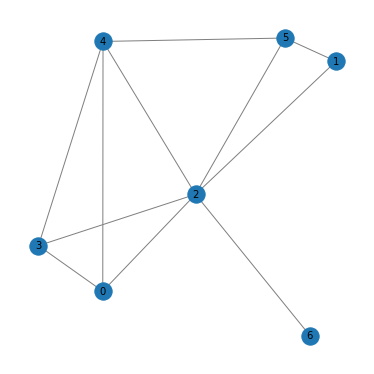

In [28]:
np.random.seed(212)
n = 7  # Number of nodes
radius = 0.5  # Distance threshold value
G = nx.random_geometric_graph(n, radius)

# Plot the generated graph
pos_generated_from_rgg = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(5,5))
nx.draw(G, pos_generated_from_rgg, with_labels=True, edge_color='gray', node_size=300, font_size=10)


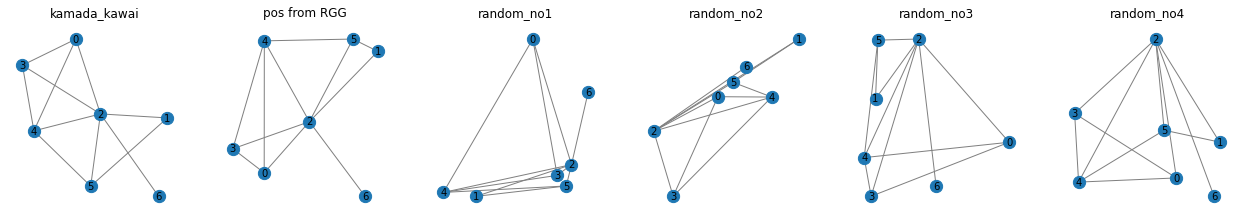

In [29]:
layouts = draw_five_layouts(G, 2, pos_generated_from_rgg)
save_posdfs(G, layouts, 2, pos_generated_from_rgg)

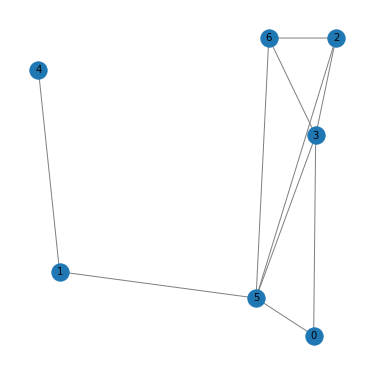

In [36]:
np.random.seed(212)
n = 7  # Number of nodes
radius = 0.6  # Distance threshold value
G = nx.random_geometric_graph(n, radius)

# Plot the generated graph
pos_generated_from_rgg = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(5,5))
nx.draw(G, pos_generated_from_rgg, with_labels=True, edge_color='gray', node_size=300, font_size=10)


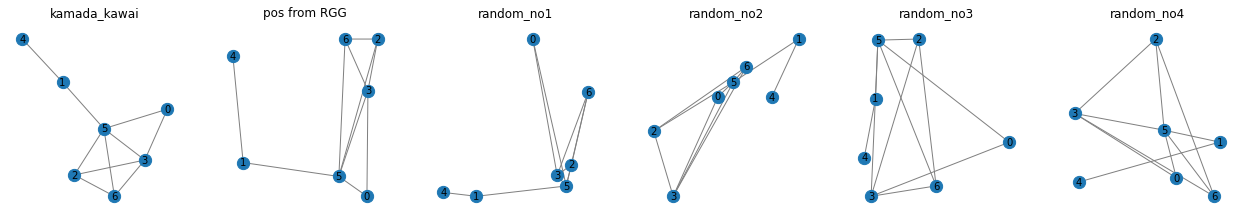

In [37]:
layouts = draw_five_layouts(G, 3, pos_generated_from_rgg)
save_posdfs(G, layouts, 3, pos_generated_from_rgg)

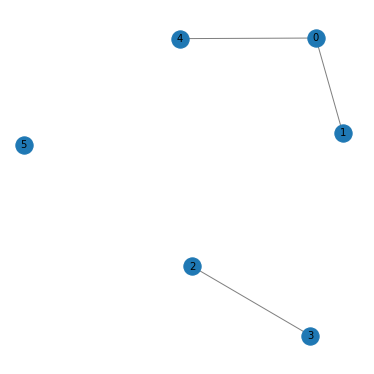

In [ ]:
np.random.seed(212)
n = 6  # Number of nodes
radius = 0.3  # Distance threshold value
G = nx.random_geometric_graph(n, radius)

# Plot the generated graph
pos_generated_from_rgg = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(5,5))
nx.draw(G, pos_generated_from_rgg, with_labels=True, edge_color='gray', node_size=300, font_size=10)


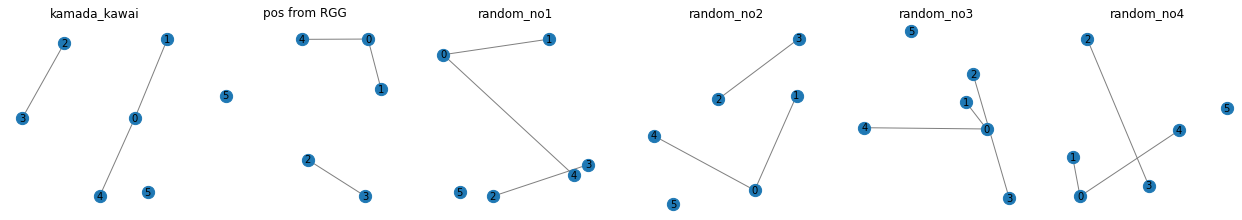

In [43]:
layouts = draw_five_layouts(G, 4, pos_generated_from_rgg)
save_posdfs(G, layouts, 4, pos_generated_from_rgg)

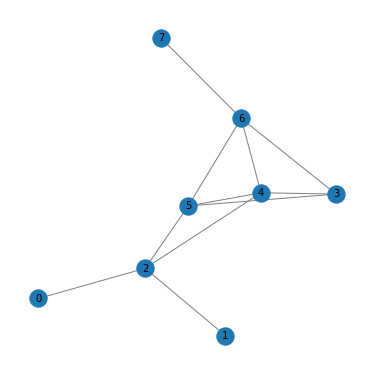

In [46]:
np.random.seed(212)
n = 8  # Number of nodes
radius = 0.4  # Distance threshold value
G = nx.random_geometric_graph(n, radius)

# Plot the generated graph
pos_generated_from_rgg = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(5,5))
nx.draw(G, pos_generated_from_rgg, with_labels=True, edge_color='gray', node_size=300, font_size=10)


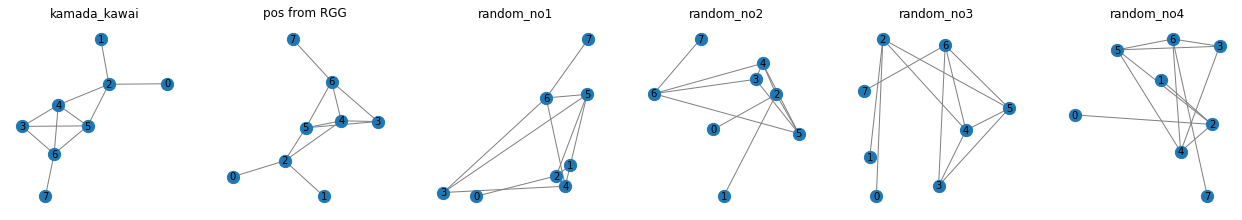

In [47]:
layouts = draw_five_layouts(G, 5, pos_generated_from_rgg)
save_posdfs(G, layouts, 5, pos_generated_from_rgg)

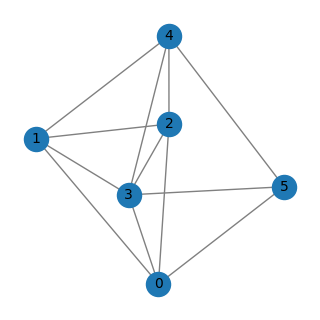

In [59]:
np.random.seed(212)
n = 6  # Number of nodes
k = 4   # Each node is connected to k nearest neighbors in ring topology
p = 0.9 # The probability of rewiring each edge
G = nx.watts_strogatz_graph(n, k, p)
plt.figure(figsize=(3,3))
nx.draw(G, with_labels=True, edge_color='gray', node_size=300, font_size=10)


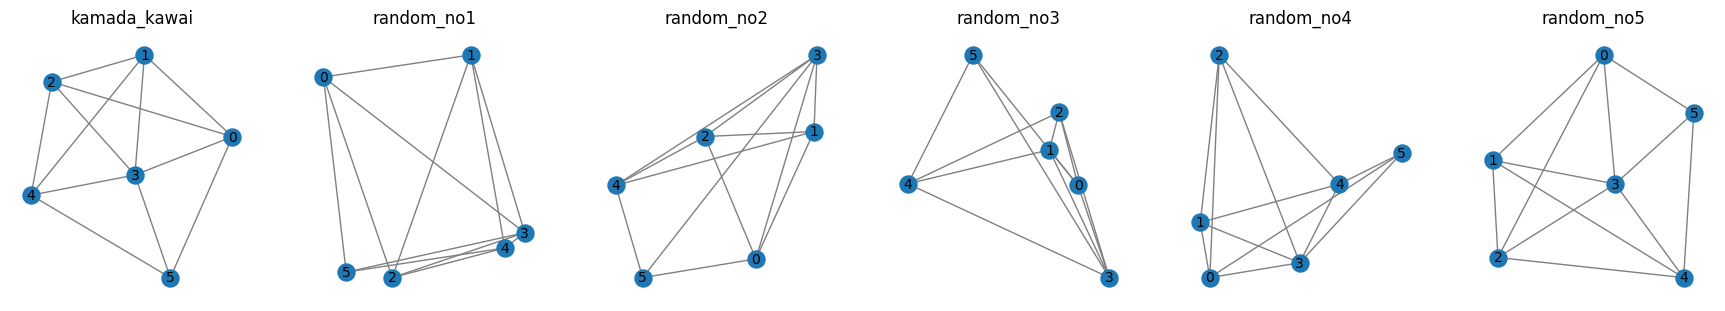

In [60]:
layouts = draw_five_layouts(G, 6)
save_posdfs(G, layouts, 6)

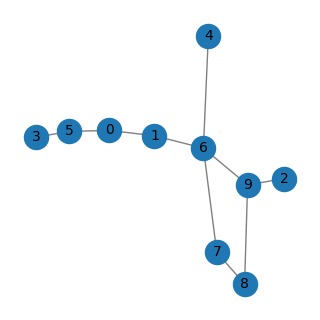

In [61]:
np.random.seed(212)
n = 10  # Number of nodes
k = 3   # Each node is connected to k nearest neighbors in ring topology
p = 0.7 # The probability of rewiring each edge
G = nx.watts_strogatz_graph(n, k, p)
plt.figure(figsize=(3,3))
nx.draw(G, with_labels=True, edge_color='gray', node_size=300, font_size=10)


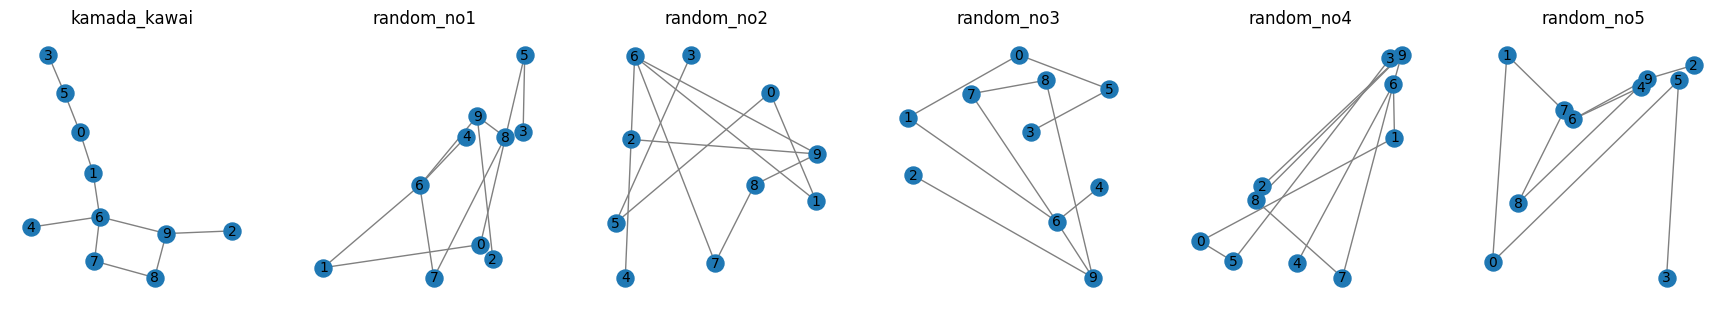

In [62]:
layouts = draw_five_layouts(G, 7)
save_posdfs(G, layouts, 7)

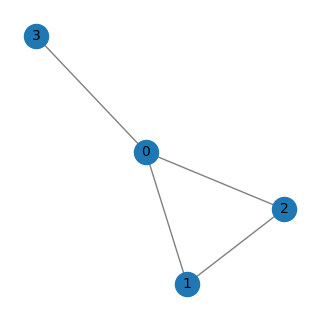

In [66]:
np.random.seed(212)
n = 4  # Number of nodes
k = 2   # Each node is connected to k nearest neighbors in ring topology
p = 0.7 # The probability of rewiring each edge
G = nx.watts_strogatz_graph(n, k, p)
plt.figure(figsize=(3,3))
nx.draw(G, with_labels=True, edge_color='gray', node_size=300, font_size=10)


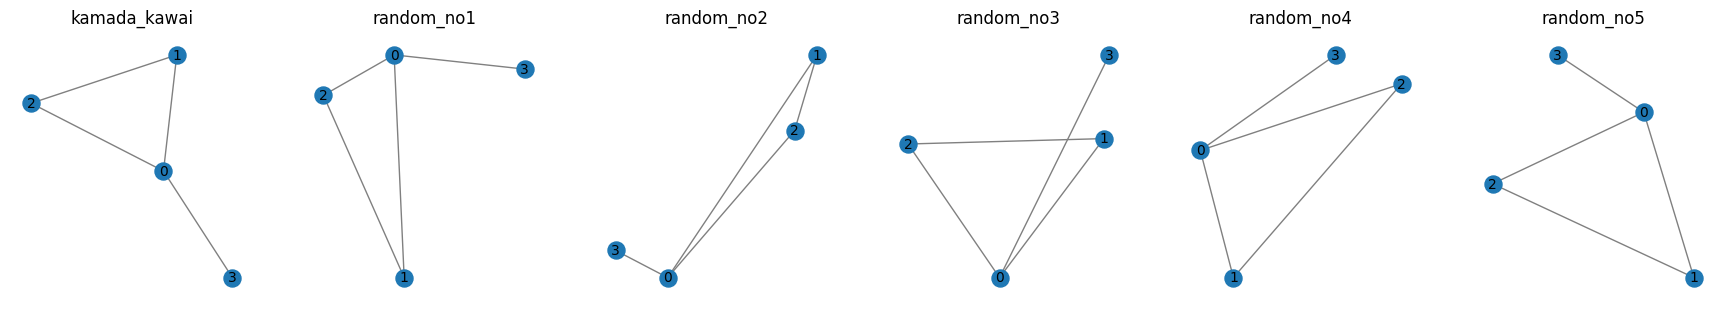

In [67]:
layouts = draw_five_layouts(G, 8)
save_posdfs(G, layouts, 8)

In [45]:

%load_ext autoreload
%autoreload 3
from graph_metric_script import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


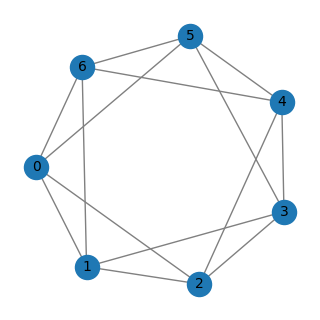

In [81]:
np.random.seed(212)
n = 7  # Number of nodes
k = 4   # Each node is connected to k nearest neighbors in ring topology
p = 0.1 # The probability of rewiring each edge
G = nx.watts_strogatz_graph(n, k, p)
plt.figure(figsize=(3,3))
nx.draw(G, with_labels=True, edge_color='gray', node_size=300, font_size=10)


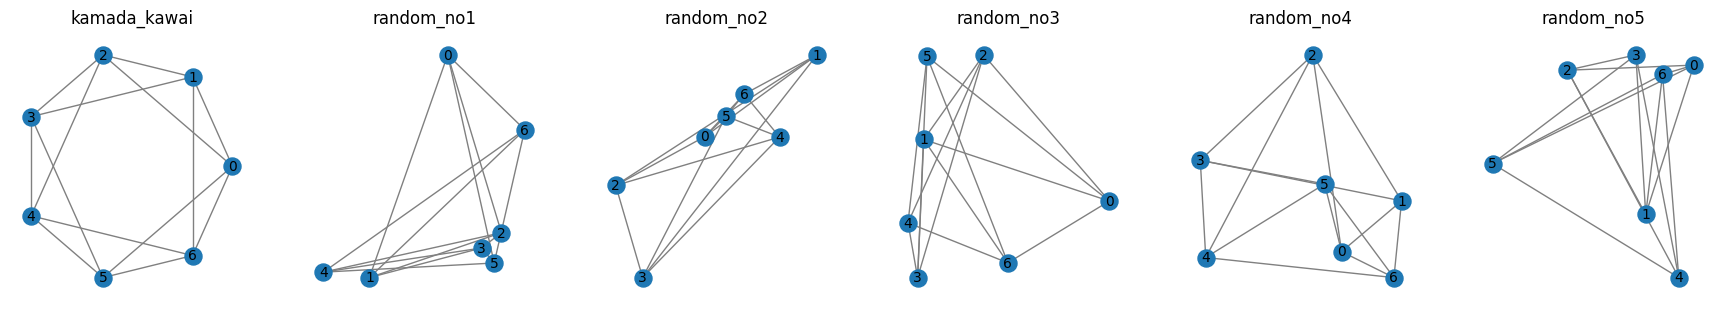

In [82]:
layouts = draw_five_layouts(G, 9)
save_posdfs(G, layouts, 9)